In [12]:
import pandas as pd
import numpy as np

#Data processing
patients = pd.read_csv('Patients.csv')
diagnosis = pd.read_csv('Diagnosis.csv')
outcomes = pd.read_csv('Outcomes.csv')
labs =pd.read_csv('labs.csv')



In [13]:
patients = patients.merge(diagnosis,on ='DiagnosisID')

patients = patients.merge(outcomes,on ='OutcomeID')

In [14]:
patients['AdmissionDate'] =pd.to_datetime(patients['AdmissionDate'])
patients['DischargeDate'] =pd.to_datetime(patients['DischargeDate'])
patients['LengthOfstay'] =(patients['DischargeDate'] - patients['AdmissionDate']).dt.days


In [22]:
patients['OutcomeEmcoded'] = patients['OutcomeName'].map({'Recovered':0, 'Complicated':1,'Deceased':1})

In [23]:
patients['HighRisk'] =np.where((patients['Age']>65) | (patients['OutcomeName'].isin(['Complicated', 'Deceased'])),1,0)

In [25]:
patients.head(5)


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost,DiagnosisName,OutcomeName,LengthOfstay,OutcomeEmcoded,HighRisk
0,1,Edward Montes,68,M,2,2025-03-22,2025-04-04,1,4443,Diabetes,Recovered,13,0,1
1,2,Jessica Zimmerman,81,M,2,2025-03-31,2025-04-02,2,4265,Diabetes,Complicated,2,1,1
2,3,Gina Alexander,58,M,6,2025-01-08,2025-03-13,1,4188,COPD,Recovered,64,0,0
3,4,Lori Green,44,F,3,2025-04-03,2025-04-05,1,9783,Heart Disease,Recovered,2,0,0
4,5,Jack Logan,72,F,9,2025-06-03,2025-06-04,1,5005,Kidney Disease,Recovered,1,0,1


In [27]:
abnormal_conditions = {
    'Blood Sugar': lambda x: x>120,
    'Cholesterol': lambda x: x > 200,
    'Hemoglobin': lambda x: x<13
}

def count_abnormal_labs(patient_id):
    patient_labs = labs[labs['PatientID'] == patient_id]
    count = 0
    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[patient_labs['TestName'] == test_name]
        count += test_results['Result'].apply(condition).sum()
    return count

patients['AbnormalLabCount'] = patients['PatientID'].apply(count_abnormal_labs)

Model Training

In [ ]:
features = patients[['Age', 'LengthOfstay', 'TreatmentCost']]
target = patients['OutcomeEmcoded']


In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state=42)

ML-
1. supervised - input + output - linear Regression, Logistic Regression etc
2. unsupervised - input
3. reinforcment - rewards


In [34]:

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 500)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print("Classification Report: ")
print(classification_report(y_test, y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.71      0.95      0.81        43

    accuracy                           0.68        60
   macro avg       0.35      0.48      0.41        60
weighted avg       0.51      0.68      0.58        60



ROC Curve

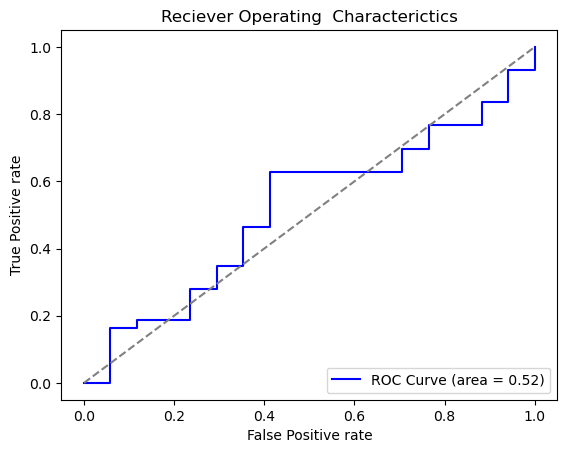

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color = 'blue', label = f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--')
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
plt.title('Reciever Operating  Characterictics')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import joblib
joblib.dump(model, 'Risk_Model1.ipynb')